# ERM untied exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [2]:
run_id_S = "20251212_1957" # S 
run_id_tied = "20251213_1322" # tied
run_id_untied_1 = "20251212_2158" # untied rho - 1.0
run_id_untied_075 = "20251213_1005" # untied rho - 0.75
run_id_untied_15 = "20251213_1804" # untied rho - 1.5

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

run_dir_untied_1 = f"../results/run_{run_id_untied_1}/"
config_path_untied_1 = f"../results/run_{run_id_untied_1}/config.csv"
base_path_untied_1 = f"../results/run_{run_id_untied_1}/summary.csv"

run_dir_untied_075 = f"../results/run_{run_id_untied_075}/"
config_path_untied_075 = f"../results/run_{run_id_untied_075}/config.csv"
base_path_untied_075 = f"../results/run_{run_id_untied_075}/summary.csv"

run_dir_untied_15 = f"../results/run_{run_id_untied_15}/"
config_path_untied_15 = f"../results/run_{run_id_untied_15}/config.csv"
base_path_untied_15 = f"../results/run_{run_id_untied_15}/summary.csv"

plot_path = f"../results/run_{run_id_S}/plots/"
os.makedirs(plot_path, exist_ok=True)

Loaded:
  S             : 75 rows
  Tied          : 90 rows
  Untied (1.0)  : 105 rows
  Untied (0.75) : 105 rows

Using λ = 0.0001
  S rows             = 15
  Tied rows          = 15
  Untied (1.0) rows  = 15
  Untied (0.75) rows = 15

✅ Saved plot: ../results/run_20251212_1957/plots/LabelError_All_Comparison_lambda0.0001.png


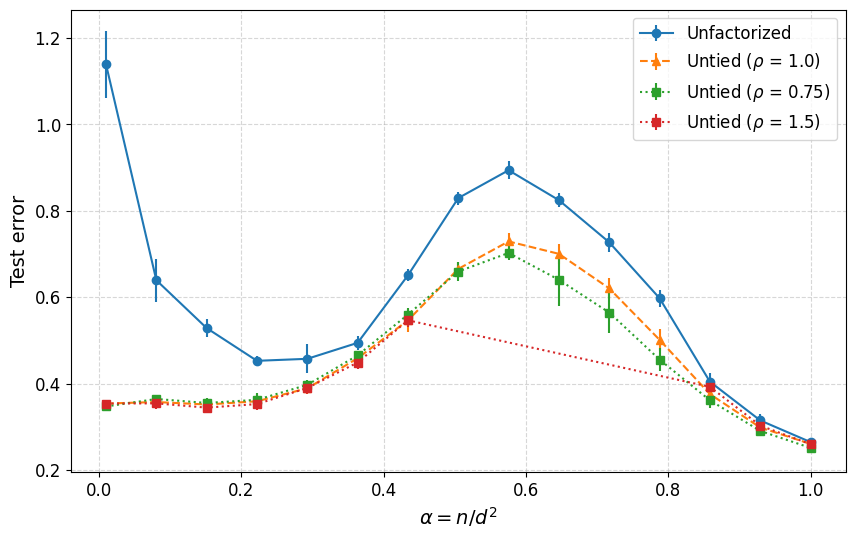

In [3]:
from email.mime import base
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Construction des chemins
base_path_S = f"../results/run_{run_id_S}/summary.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"
base_path_untied_1 = f"../results/run_{run_id_untied_1}/summary.csv"
base_path_untied_075 = f"../results/run_{run_id_untied_075}/summary.csv"
base_path_untied_15 = f"../results/run_{run_id_untied_15}/summary.csv"

# Dossier de sauvegarde
plot_path = f"../results/run_{run_id_S}/plots/"
os.makedirs(plot_path, exist_ok=True)

# --- 2. CHOIX DU LAMBDA ---
lam_fixed = 0.0001

# --- 3. CHARGEMENT DES DONNÉES ---
# On ajoute le try/except pour éviter que ça plante si un fichier manque
try:
    df_S = pd.read_csv(base_path_S)
    df_tied = pd.read_csv(base_path_tied)  
    df_untied_1 = pd.read_csv(base_path_untied_1)
    df_untied_075 = pd.read_csv(base_path_untied_075)
    df_untied_15 = pd.read_csv(base_path_untied_15)
except FileNotFoundError as e:
    print(f"❌ Erreur : Fichier introuvable. Vérifiez les chemins.\n{e}")
    exit()

print("Loaded:")
print(f"  S             : {len(df_S)} rows")
print(f"  Tied          : {len(df_tied)} rows") # <--- Ajouté
print(f"  Untied (1.0)  : {len(df_untied_1)} rows")
print(f"  Untied (0.75) : {len(df_untied_075)} rows")

# --- 4. FILTRAGE PAR LAMBDA ---
df_S_f = df_S[df_S["lam"] == lam_fixed].sort_values("alpha")
df_tied_f = df_tied[df_tied["lam"] == lam_fixed].sort_values("alpha") # <--- Ajouté
df_untied_1_f = df_untied_1[df_untied_1["lam"] == lam_fixed].sort_values("alpha")
df_untied_075_f = df_untied_075[df_untied_075["lam"] == lam_fixed].sort_values("alpha")
df_untied_15_f = df_untied_15[df_untied_15["lam"] == lam_fixed].sort_values("alpha")

print(f"\nUsing λ = {lam_fixed}")
print(f"  S rows             = {len(df_S_f)}")
print(f"  Tied rows          = {len(df_tied_f)}")
print(f"  Untied (1.0) rows  = {len(df_untied_1_f)}")
print(f"  Untied (0.75) rows = {len(df_untied_075_f)}\n")

# --- 5. PLOT ---
plt.figure(figsize=(10, 6)) # Légèrement plus large pour la légende

# --- A. Unfactorized (S) ---
plt.errorbar(
    df_S_f["alpha"],
    df_S_f["label_err_mean_noise"],
    yerr=df_S_f.get("label_err_std_noise", 0),
    marker="o",
    linestyle="-",
    capsize=0,
    label="Unfactorized"
)

# --- C. Untied (1.0) ---
plt.errorbar(
    df_untied_1_f["alpha"],
    df_untied_1_f["label_err_mean_noise"],
    yerr=df_untied_1_f.get("label_err_std_noise", 0),
    marker="^",
    linestyle="--",
    capsize=0,
    label=r"Untied ($\rho$ = 1.0)"
)

# --- D. Untied (0.75) ---
plt.errorbar(
    df_untied_075_f["alpha"],
    df_untied_075_f["label_err_mean_noise"],
    yerr=df_untied_075_f.get("label_err_std_noise", 0),
    marker="s",
    linestyle=":",
    capsize=0,
    label=r"Untied ($\rho$ = 0.75)"
)

# --- D. Untied (1.5) ---
plt.errorbar(
    df_untied_15_f["alpha"],
    df_untied_15_f["label_err_mean_noise"],
    yerr=df_untied_15_f.get("label_err_std_noise", 0),
    marker="s",
    linestyle=":",
    capsize=0,
    label=r"Untied ($\rho$ = 1.5)"
)

# --- MISE EN FORME ---
# Calcul dynamique des limites x pour inclure toutes les courbes
all_alphas = pd.concat([
    df_S_f["alpha"], 
    df_tied_f["alpha"], 
    df_untied_1_f["alpha"], 
    df_untied_075_f["alpha"]
])

plt.xlabel(r"$\alpha = n / d^2$", fontsize=14)
plt.ylabel("Test error", fontsize=14)
# plt.title(f"Test error vs α (λ = {lam_fixed})", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

# Amélioration des ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- SAUVEGARDE ---
save_path = os.path.join(plot_path, f"LabelError_All_Comparison_lambda{lam_fixed}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Saved plot: {save_path}")

plt.show()

Loaded:
  S             : 75 rows
  Tied          : 90 rows
  Untied (1.0)  : 105 rows
  Untied (0.75) : 105 rows

Using λ = 0.0001
  S rows             = 15
  Tied rows          = 15
  Untied (1.0) rows  = 15
  Untied (0.75) rows = 15

✅ Saved plot: ../results/run_20251212_1957/plots/LabelError_All_Comparison_lambda_untied_0.0001.png


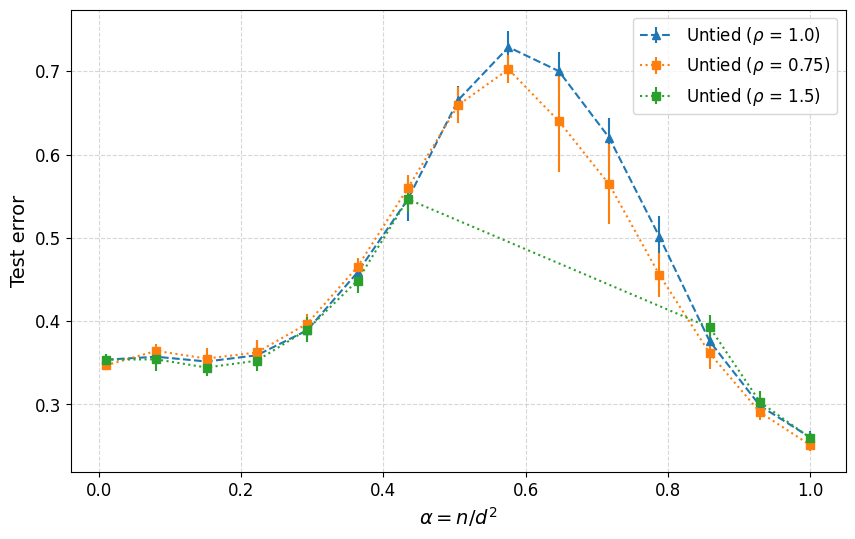

In [4]:
from email.mime import base
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Construction des chemins
base_path_S = f"../results/run_{run_id_S}/summary.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"
base_path_untied_1 = f"../results/run_{run_id_untied_1}/summary.csv"
base_path_untied_075 = f"../results/run_{run_id_untied_075}/summary.csv"
base_path_untied_15 = f"../results/run_{run_id_untied_15}/summary.csv"

# Dossier de sauvegarde
plot_path = f"../results/run_{run_id_S}/plots/"
os.makedirs(plot_path, exist_ok=True)

# --- 2. CHOIX DU LAMBDA ---
lam_fixed = 0.0001

# --- 3. CHARGEMENT DES DONNÉES ---
# On ajoute le try/except pour éviter que ça plante si un fichier manque
try:
    df_S = pd.read_csv(base_path_S)
    df_tied = pd.read_csv(base_path_tied)  
    df_untied_1 = pd.read_csv(base_path_untied_1)
    df_untied_075 = pd.read_csv(base_path_untied_075)
    df_untied_15 = pd.read_csv(base_path_untied_15)
except FileNotFoundError as e:
    print(f"❌ Erreur : Fichier introuvable. Vérifiez les chemins.\n{e}")
    exit()

print("Loaded:")
print(f"  S             : {len(df_S)} rows")
print(f"  Tied          : {len(df_tied)} rows") # <--- Ajouté
print(f"  Untied (1.0)  : {len(df_untied_1)} rows")
print(f"  Untied (0.75) : {len(df_untied_075)} rows")

# --- 4. FILTRAGE PAR LAMBDA ---
df_S_f = df_S[df_S["lam"] == lam_fixed].sort_values("alpha")
df_tied_f = df_tied[df_tied["lam"] == lam_fixed].sort_values("alpha") # <--- Ajouté
df_untied_1_f = df_untied_1[df_untied_1["lam"] == lam_fixed].sort_values("alpha")
df_untied_075_f = df_untied_075[df_untied_075["lam"] == lam_fixed].sort_values("alpha")
df_untied_15_f = df_untied_15[df_untied_15["lam"] == lam_fixed].sort_values("alpha")

print(f"\nUsing λ = {lam_fixed}")
print(f"  S rows             = {len(df_S_f)}")
print(f"  Tied rows          = {len(df_tied_f)}")
print(f"  Untied (1.0) rows  = {len(df_untied_1_f)}")
print(f"  Untied (0.75) rows = {len(df_untied_075_f)}\n")

# --- 5. PLOT ---
plt.figure(figsize=(10, 6)) # Légèrement plus large pour la légende

# --- C. Untied (1.0) ---
plt.errorbar(
    df_untied_1_f["alpha"],
    df_untied_1_f["label_err_mean_noise"],
    yerr=df_untied_1_f.get("label_err_std_noise", 0),
    marker="^",
    linestyle="--",
    capsize=0,
    label=r"Untied ($\rho$ = 1.0)"
)

# --- D. Untied (0.75) ---
plt.errorbar(
    df_untied_075_f["alpha"],
    df_untied_075_f["label_err_mean_noise"],
    yerr=df_untied_075_f.get("label_err_std_noise", 0),
    marker="s",
    linestyle=":",
    capsize=0,
    label=r"Untied ($\rho$ = 0.75)"
)

# --- D. Untied (1.5) ---
plt.errorbar(
    df_untied_15_f["alpha"],
    df_untied_15_f["label_err_mean_noise"],
    yerr=df_untied_15_f.get("label_err_std_noise", 0),
    marker="s",
    linestyle=":",
    capsize=0,
    label=r"Untied ($\rho$ = 1.5)"
)

# --- MISE EN FORME ---
# Calcul dynamique des limites x pour inclure toutes les courbes
all_alphas = pd.concat([
    df_S_f["alpha"], 
    df_tied_f["alpha"], 
    df_untied_1_f["alpha"], 
    df_untied_075_f["alpha"]
])

plt.xlabel(r"$\alpha = n / d^2$", fontsize=14)
plt.ylabel("Test error", fontsize=14)
# plt.title(f"Test error vs α (λ = {lam_fixed})", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

# Amélioration des ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- SAUVEGARDE ---
save_path = os.path.join(plot_path, f"LabelError_All_Comparison_lambda_untied_{lam_fixed}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Saved plot: {save_path}")

plt.show()